In [1]:
# Problem: Predict diabetes onset using Decision Trees and Random Forests
# Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1: Load the data
data = pd.read_csv('diabetes.csv')
print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
#Step 2: Split the data into features and target
X = data.drop('Outcome', axis=1) # Feature
y = data['Outcome'] # Target

In [5]:
# Step 3: Split into training and validation dataset.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Step 4: Build and Train the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
# Step 5: Build and Train the Random Forest Classifier
random_forest = RandomForestClassifier(n_estimators=100, min_samples_leaf=1, min_samples_split=5, random_state=42)
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# Step 6: Make the predictions & Evaluate the models.
dt_predictions = decision_tree.predict(X_val)
rf_predictions = random_forest.predict(X_val)

# Decision Tree.
dt_accuracy = accuracy_score(y_val, dt_predictions)
dt_confusion_matrix = confusion_matrix(y_val, dt_predictions)
dt_classification_report = classification_report(y_val, dt_predictions)

print(f"Decision Tree Accuracy Score: {dt_accuracy}")
print(f"Decision Tree Confusion Matrix: {dt_confusion_matrix}")
print(f"Decision Tree Classification Report: {dt_classification_report}")

# Random Forest
rf_accuracy = accuracy_score(y_val, rf_predictions)
rf_confusion_matrix = confusion_matrix(y_val, rf_predictions)
rf_classification_report = classification_report(y_val, rf_predictions)

print(f"Random Forest Accuracy Score: {rf_accuracy}")
print(f"Random Forest Confusion Matrix: {rf_confusion_matrix}")
print(f"Random Forest Classification Report: {rf_classification_report}")

Decision Tree Accuracy Score: 0.7467532467532467
Decision Tree Confusion Matrix: [[75 24]
 [15 40]]
Decision Tree Classification Report:               precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Random Forest Accuracy Score: 0.7337662337662337
Random Forest Confusion Matrix: [[77 22]
 [19 36]]
Random Forest Classification Report:               precision    recall  f1-score   support

           0       0.80      0.78      0.79        99
           1       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



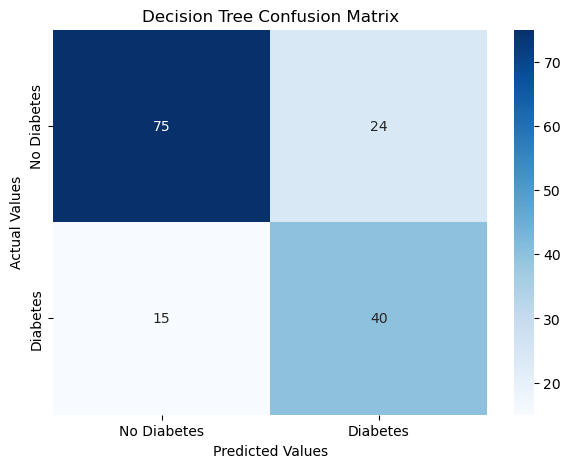

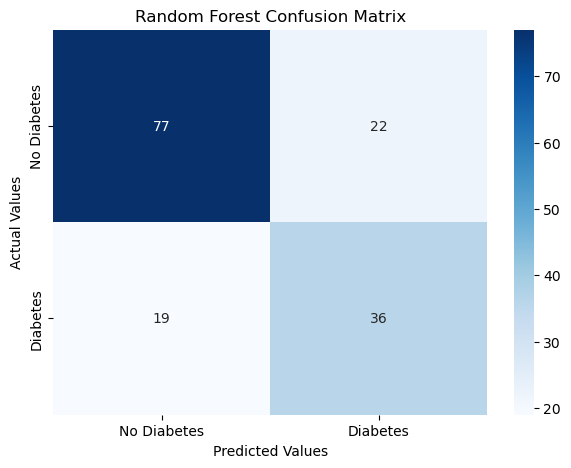

In [10]:
# Step 7: Visualization
# Decision Tree
plt.figure(figsize=(7,5))
sns.heatmap(dt_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Random Forest
plt.figure(figsize=(7,5))
sns.heatmap(rf_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Random Forest Confusion Matrix')
plt.show()
